In [1]:
from ucimlrepo import fetch_ucirepo 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

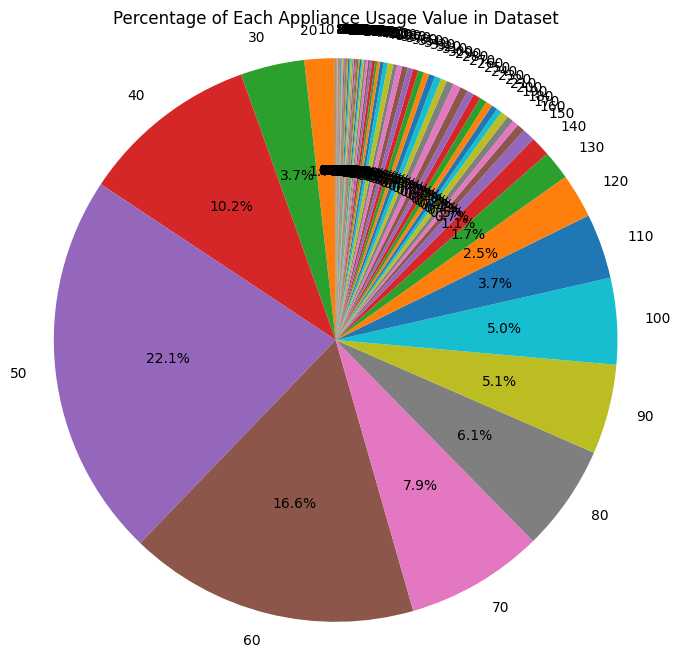

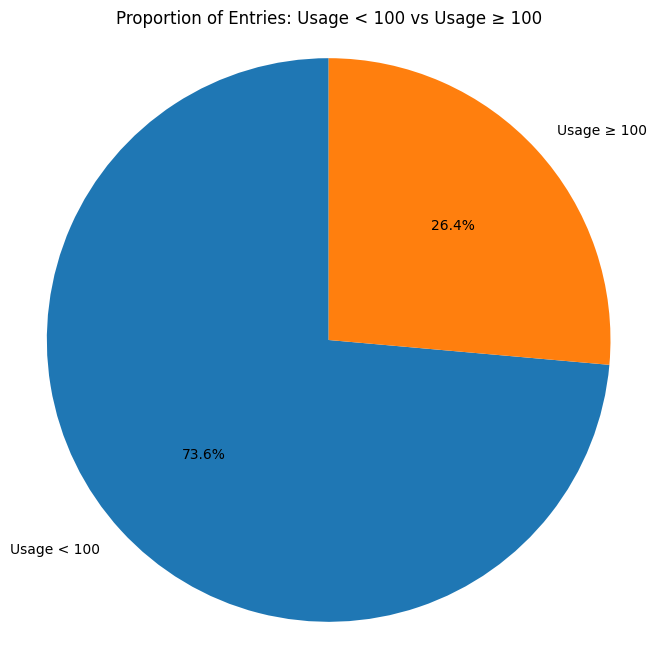

In [2]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

USAGE_LEVEL = 70
# Load dataset
appliances = fetch_ucirepo(id=374)
df = pd.concat([appliances.data.features, appliances.data.targets], axis=1)

# Fix malformed timestamp format and extract hour
df['date'] = df['date'].str.replace(r'(\d{4}-\d{2}-\d{2})(\d{2}:\d{2}:\d{2})', r'\1 \2', regex=True)
df['date'] = pd.to_datetime(df['date'])
df['hour'] = df['date'].dt.hour

# Define features and target
features = ['T1', 'RH_1', 'T2', 'RH_2', 'T_out']
target = 'Appliances'

# Print unique appliance usage values and their counts
appliance_counts = df['Appliances'].value_counts().sort_index()
plt.figure(figsize=(8, 8))
plt.pie(appliance_counts, labels=appliance_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Percentage of Each Appliance Usage Value in Dataset")
plt.axis('equal')
plt.show()

# Additional plot: Pie chart of entries under 100 usage and over 100 usage
usage_under_100 = (df['Appliances'] < 100).sum()
usage_over_100 = (df['Appliances'] >= 100).sum()
plt.figure(figsize=(8, 8))
plt.pie([usage_under_100, usage_over_100], labels=['Usage < 100', 'Usage ≥ 100'], autopct='%1.1f%%', startangle=90)
plt.title("Proportion of Entries: Usage < 100 vs Usage ≥ 100")
plt.axis('equal')
plt.show()

# # Second plot: remove appliance usage values that make up under 5% of the dataset
# total = appliance_counts.sum()
# threshold = 0.04 * total
# filtered_counts = appliance_counts[appliance_counts >= threshold]

# plt.figure(figsize=(8, 8))
# plt.pie(filtered_counts, labels=filtered_counts.index, autopct='%1.1f%%', startangle=90)
# plt.title("Percentage of Appliance Usage Values (≥5% of Dataset)")
# plt.axis('equal')
# plt.show()

# # Third plot: undersample the remaining classes to balance the dataset
# # Get the indices for each class in filtered_counts
# filtered_classes = filtered_counts.index
# dfs = []
# min_count = filtered_counts.min()
# for val in filtered_classes:
#     class_indices = df[df['Appliances'] == val].index
#     sampled_indices = np.random.choice(class_indices, min_count, replace=False)
#     dfs.append(df.loc[sampled_indices])
# balanced_df = pd.concat(dfs).reset_index(drop=True)

# # Plot the balanced class distribution
# balanced_counts = balanced_df['Appliances'].value_counts().sort_index()
# plt.figure(figsize=(8, 8))
# plt.pie(balanced_counts, labels=balanced_counts.index, autopct='%1.1f%%', startangle=90)
# plt.title("Percentage of Appliance Usage Values (Balanced by Undersampling)")
# plt.axis('equal')
# plt.show()

# Global train-test split (80/20)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
# Reset index for sequence alignment
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)


In [3]:
def apply_bias(df, strategy):
    if strategy == 'none':
        return df.copy()
    elif strategy == 'time_of_day':
        return df[df['hour'] < 12].copy()
    elif strategy == 'room_temperature':
        return df[df['T_out'] > 10].copy()
    elif strategy == 'cold_weather':
        return df[df['T_out'] < 5].copy()
    elif strategy == 'low_usage':
        mask_low  = df[target] < USAGE_LEVEL
        mask_high = ~mask_low
        low_kept  = df[mask_low].sample(frac=0.2, random_state=42)
        high_kept = df[mask_high]   # keep all the high‑usage rows
        return pd.concat([low_kept, high_kept]).reset_index(drop=True)
    elif strategy == 'appliances':
        return df[df['Appliances'] != 60].copy()
    else:
        raise ValueError(f"Unknown strategy: {strategy}")


In [4]:
class LSTMRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=32):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
    def forward(self, x):
        _, (hn, _) = self.lstm(x)
        return self.fc(hn[-1]).squeeze()

def to_sequences(df_seq, seq_len=5):
    Xs, ys = [], []
    for i in range(len(df_seq) - seq_len):
        Xs.append(df_seq[features].iloc[i:i+seq_len].values)
        ys.append(df_seq[target].iloc[i+seq_len])
    return torch.tensor(np.array(Xs), dtype=torch.float32), torch.tensor(np.array(ys), dtype=torch.float32)


In [5]:
strategies = ['none','time_of_day','room_temperature','cold_weather','low_usage']
results = []

for strat in strategies:
    # Apply bias to training set
    df_train_biased = apply_bias(train_df, strat)
    if len(df_train_biased) < 50:
        print(f"Skipping strategy {strat}: too few training samples {len(df_train_biased)}")
        continue

    # Create sequences
    X_train_seq, y_train_seq = to_sequences(df_train_biased)
    X_test_seq, y_test_seq = to_sequences(test_df)
    
    # Train-test split for sequences
    train_size = int(0.8 * len(X_train_seq))
    X_tr, X_val = X_train_seq[:train_size], X_train_seq[train_size:]
    y_tr, y_val = y_train_seq[:train_size], y_train_seq[train_size:]

    # DataLoader
    train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=64, shuffle=True)

    # Initialize model
    model = LSTMRegressor(input_dim=len(features))
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    # Train for 20 epochs
    for epoch in range(20):
        model.train()
        epoch_loss = 0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
    
    # Evaluate on full test set
    model.eval()
    with torch.no_grad():
        preds = model(X_test_seq).numpy()
        trues = y_test_seq.numpy()
    r2_all = r2_score(trues, preds)

    # Subgroup evaluation based on strategy
    meta = test_df.iloc[5:].reset_index(drop=True)
    if strat == 'time_of_day':
        mask = meta['hour'] < 12; grp1='Morning'; grp2='Afternoon'
    elif strat == 'room_temperature':
        mask = meta['T_out'] > 10; grp1='Warm'; grp2='Cool'
    elif strat == 'cold_weather':
        mask = meta['T_out'] < 5; grp1='Cold'; grp2='Not Cold'
    elif strat == 'low_usage':
        mask = meta[target] < USAGE_LEVEL; grp1='Low Usage'; grp2='High Usage'
    else:
        results.append({'Strategy': strat, 'Group': 'All', 'R2': r2_all})
        continue

    # Compute subgroup R2 if sufficient samples
    if mask.sum() >= 2:
        results.append({'Strategy': strat, 'Group': grp1, 'R2': r2_score(trues[mask], preds[mask])})
    if (~mask).sum() >= 2:
        results.append({'Strategy': strat, 'Group': grp2, 'R2': r2_score(trues[~mask], preds[~mask])})
    # Also include overall
    results.append({'Strategy': strat, 'Group': 'All', 'R2': r2_all})
    if strat == 'low_usage':
        print("\n=== LOW_USAGE DIAGNOSTICS ===")
        # 1) Biased train set sizes
        n_train_biased = len(df_train_biased)
        mask_train = df_train_biased[target] < USAGE_LEVEL
        n_low_train  = mask_train.sum()
        n_high_train = n_train_biased - n_low_train
        print(f"Biased TRAIN  → total={n_train_biased}, low_usage={n_low_train}, high_usage={n_high_train}")

        # 2) Test set sizes
        n_test_total = len(meta)
        n_low_test   = mask.sum()
        n_high_test  = (~mask).sum()
        print(f"TEST           → total={n_test_total}, low_usage={n_low_test}, high_usage={n_high_test}")

        # 3) SNR on under‑represented test slice
        low_preds  = preds[mask]
        low_trues  = trues[mask]
        signal_var = np.var(low_preds)
        noise_var  = np.var(low_trues - low_preds)
        snr = signal_var / noise_var if noise_var>0 else float('nan')
        print(f"SNR (low_usage test) = {snr:.2f}")

        # 4) R² results
        r2_low = r2_score(low_trues, low_preds) if n_low_test>=2 else float('nan')
        print(f"R² low_usage = {r2_low:.3f}")
        print(f"R² overall   = {r2_all:.3f}")
        print("=== end diagnostics ===\n")
# Compile results
res_df = pd.DataFrame(results)
res_df


=== LOW_USAGE DIAGNOSTICS ===
Biased TRAIN  → total=8894, low_usage=1723, high_usage=7171
TEST           → total=3942, low_usage=2124, high_usage=1818
SNR (low_usage test) = 0.00
R² low_usage = -2.557
R² overall   = -0.099
=== end diagnostics ===



,Strategy,Group,R2
0,none,All,-0.008080
1,time_of_day,Morning,-0.062112
2,time_of_day,Afternoon,-0.355175
3,time_of_day,All,-0.185264
4,room_temperature,Warm,-0.472656
5,room_temperature,Cool,-0.343533
6,room_temperature,All,-0.376568
7,cold_weather,Cold,-0.204774
8,cold_weather,Not Cold,-0.338179
9,cold_weather,All,-0.289742


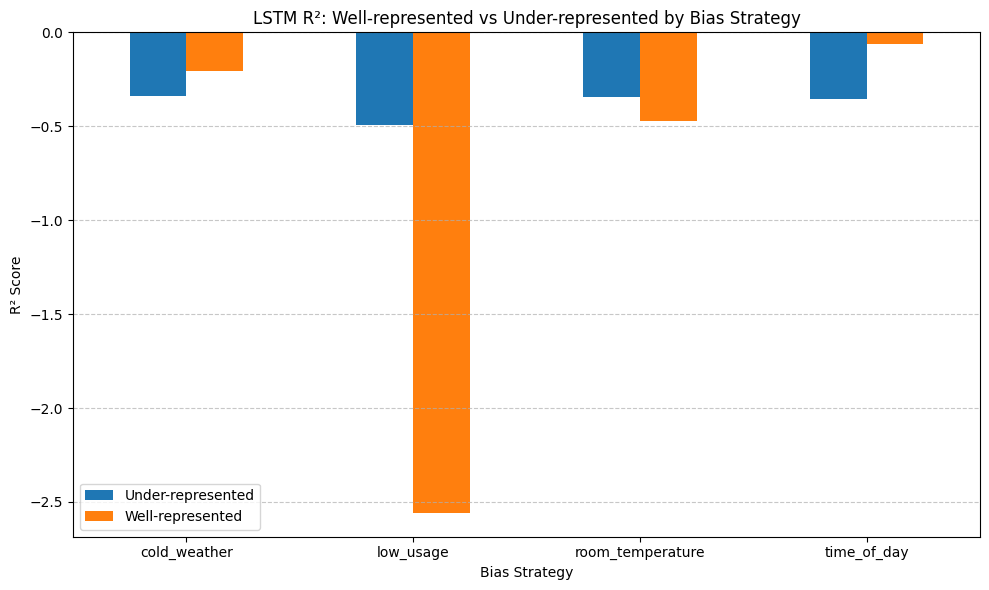

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assume res_df has columns: Strategy, Group, R2
# Example values for Group: 
#   time_of_day → ["Morning" (well), "Afternoon" (under)]
#   room_temperature → ["Warm", "Cool"], etc.

# 1) Filter out the baseline "All"
df_plot = res_df[res_df['Group'] != 'All'].copy()

# 2) Rename groups to "Well-represented" vs "Under-represented"
group_map = {
    'Morning': 'Well-represented', 'Warm': 'Well-represented',
    'Cold': 'Well-represented', 'Low Usage': 'Well-represented',
    'Afternoon': 'Under-represented', 'Cool': 'Under-represented',
    'Not Cold': 'Under-represented', 'High Usage': 'Under-represented'
}
df_plot['Type'] = df_plot['Group'].map(group_map)

# 3) Pivot so each row is a strategy, columns are the two types
pivot = df_plot.pivot(index='Strategy', columns='Type', values='R2')

# 4) Plot
pivot.plot(kind='bar', figsize=(10,6))
plt.title("LSTM R²: Well-represented vs Under-represented by Bias Strategy")
plt.ylabel("R² Score")
plt.xlabel("Bias Strategy")
plt.xticks(rotation=0)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.legend(title="")
plt.tight_layout()
plt.show()
